# Lab 2: Data Preparation for Machine Learning on `crop_production.csv`

## Aim
This lab focuses on turning a raw agricultural dataset into something a machine learning model can work with more comfortably. The main idea is not just to clean the file, but to reshape it in a way that makes patterns easier for algorithms to learn.

## What this notebook covers
In this notebook, the workflow moves a little closer to actual model preparation:
- inspect the dataset,
- separate numeric and categorical features,
- encode text-based variables,
- scale numeric columns,
- create a few meaningful transformed features,
- and prepare the final feature matrix.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## Step 1: Load the dataset
The crop production dataset is used here because it contains a mix of numeric and categorical information, which makes it a good example for feature preparation. The notebook starts the same way as any sensible analysis should: by opening the file and looking at it before making assumptions.


In [2]:
crop_df = pd.read_csv('crop_production.csv')
crop_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## Step 2: Understand the structure
At this stage, the notebook is just asking practical questions. Which columns are categories? Which are numeric? Are there missing values? Are some columns likely to need transformation before modeling?


In [3]:
print('Shape:', crop_df.shape)
print('Columns:')
print(crop_df.columns.tolist())
print('Data types:')
print(crop_df.dtypes)


Shape: (246091, 7)
Columns:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']
Data types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object


In [4]:
(crop_df.isna().mean() * 100).sort_values(ascending=False).to_frame('missing_percent').head(15)


,missing_percent
Production,1.515699
District_Name,0.000000
State_Name,0.000000
Crop_Year,0.000000
Season,0.000000
Crop,0.000000
Area,0.000000


Even when a dataset looks neat at first glance, machine learning usually asks for more discipline. Algorithms prefer numbers, and they also behave better when numeric columns are on reasonably comparable scales.


## Step 3: Handle missing values
A light-touch cleaning step comes first. Missing values in categorical columns are filled with a readable placeholder, while numeric missing values are filled using the median so that the effect of extreme values stays limited.


In [5]:
prepared_df = crop_df.copy()

cat_cols = prepared_df.select_dtypes(include=['object']).columns.tolist()
num_cols = prepared_df.select_dtypes(include=[np.number]).columns.tolist()

for col in cat_cols:
    prepared_df[col] = prepared_df[col].fillna('Unknown')

for col in num_cols:
    prepared_df[col] = prepared_df[col].fillna(prepared_df[col].median())

prepared_df.isna().sum().sum()


np.int64(0)

## Step 4: Encode categorical features
Machine learning models cannot directly use text labels like state names or crop names. So the notebook converts those labels into numeric form.

For a simple lab setting, label encoding works well enough to demonstrate the idea clearly.


In [6]:
label_encoders = {}
encoded_df = prepared_df.copy()

for col in cat_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = le

encoded_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,427,2000,1,2,1254.0,2000.0
1,0,427,2000,1,74,2.0,1.0
2,0,427,2000,1,95,102.0,321.0
3,0,427,2000,4,7,176.0,641.0
4,0,427,2000,4,22,720.0,165.0


## Step 5: Create a few helpful features
Feature engineering is where raw columns start becoming more informative. Instead of relying only on the original variables, the notebook creates a small set of derived features that may better reflect agricultural behavior.

These are simple transformations, but they help illustrate an important idea: better features often matter as much as better models.


In [7]:
engineered_df = encoded_df.copy()

cols_lower = {c.lower(): c for c in engineered_df.columns}

if 'area' in cols_lower and 'production' in cols_lower:
    area_col = cols_lower['area']
    prod_col = cols_lower['production']
    engineered_df['yield_per_area'] = engineered_df[prod_col] / (engineered_df[area_col] + 1e-6)

if 'crop_year' in cols_lower:
    year_col = cols_lower['crop_year']
    engineered_df['year_group'] = pd.cut(engineered_df[year_col], bins=5, labels=False, duplicates='drop')

engineered_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield_per_area,year_group
0,0,427,2000,1,2,1254.0,2000.0,1.594896,0
1,0,427,2000,1,74,2.0,1.0,0.500000,0
2,0,427,2000,1,95,102.0,321.0,3.147059,0
3,0,427,2000,4,7,176.0,641.0,3.642045,0
4,0,427,2000,4,22,720.0,165.0,0.229167,0


## Step 6: Scale numeric features
Many machine learning algorithms behave better when features are on similar scales. A column like production may have very large values, while an encoded category column may only range from 0 to a few dozen.

Standard scaling adjusts numeric columns so they are centered and comparable.


In [8]:
scaled_df = engineered_df.copy()
scale_cols = scaled_df.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
scaled_df[scale_cols] = scaler.fit_transform(scaled_df[scale_cols])

scaled_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield_per_area,year_group
0,-1.751735,0.616945,-1.139508,-0.909326,-1.950001,-0.212750,-0.033755,-0.053615,-1.405584
1,-1.751735,0.616945,-1.139508,-0.909326,0.163424,-0.237530,-0.033873,-0.054957,-1.405584
2,-1.751735,0.616945,-1.139508,-0.909326,0.779839,-0.235551,-0.033855,-0.051711,-1.405584
3,-1.751735,0.616945,-1.139508,1.422761,-1.803236,-0.234086,-0.033836,-0.051104,-1.405584
4,-1.751735,0.616945,-1.139508,1.422761,-1.362939,-0.223319,-0.033864,-0.055290,-1.405584


## Step 7: Inspect the transformed data
At this point, the notebook has moved from a raw agricultural file to something much closer to a model-ready feature table. A final quick check helps confirm that the transformation worked as intended.


In [9]:
scaled_df.describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
State_Name,246091.0,0.000000e+00,1.000002,-1.751735,-0.843161,-0.136493,0.973985,1.478748
District_Name,246091.0,5.543649e-17,1.000002,-1.663931,-0.894736,-0.045417,0.862660,1.781421
Crop_Year,246091.0,1.510459e-14,1.000002,-1.745305,-0.735643,0.072086,0.879816,1.889477
Season,246091.0,-9.239415e-17,1.000002,-1.686689,-0.909326,-0.131964,1.422761,2.200124
Crop,246091.0,-1.884841e-16,1.000002,-2.008707,-0.746523,-0.100754,0.985311,1.601727
Area,246091.0,-7.391532e-18,1.000002,-0.237569,-0.235987,-0.226051,-0.150640,169.587041
Production,246091.0,0.000000e+00,1.000002,-0.033874,-0.033868,-0.033830,-0.033474,73.820200
yield_per_area,246091.0,-6.467590e-18,1.000002,-0.055571,-0.054933,-0.054344,-0.052510,107.881284
year_group,246091.0,-2.217459e-17,1.000002,-1.405584,-0.672008,0.061568,0.795144,1.528720


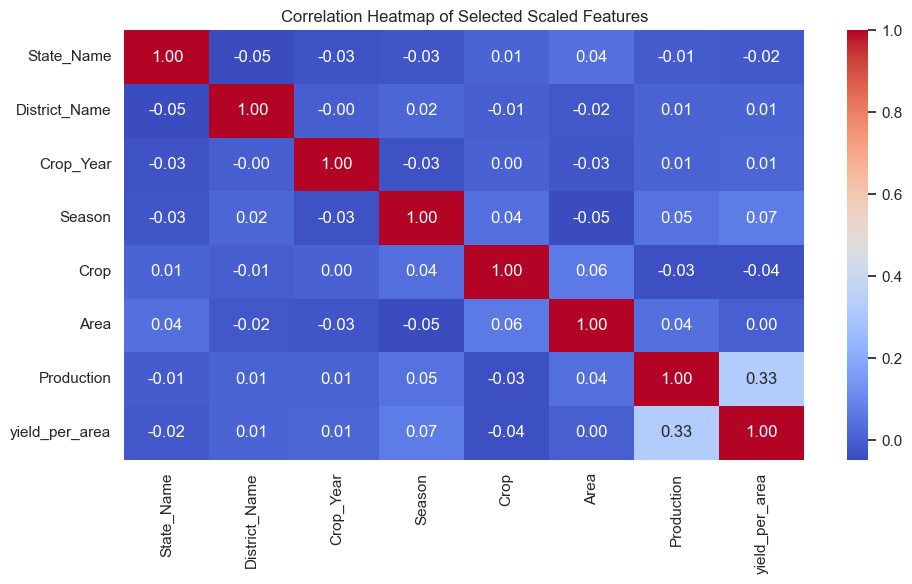

In [10]:
plt.figure(figsize=(10, 6))
selected_cols = scale_cols[:8] if len(scale_cols) >= 8 else scale_cols
sns.heatmap(scaled_df[selected_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Selected Scaled Features')
plt.tight_layout()
plt.show()


## Conclusion
This lab pushes the dataset one step closer to actual machine learning. Missing values are handled, categorical variables are encoded, new features are created, and numeric columns are scaled into a more model-friendly form.

More importantly, the notebook shows that data preparation is not just a technical ritual. It is where raw records begin to turn into usable signals.
